# МатСтат. РГР 1. Вариант 3

## В команде: Криличевский Максим, Ситдиков Рафаэль

# Описание работы

В данной работе проводится статистический анализ четырёх выборок $X_1, X_2, X_3, X_4$ объёмом $n=200$ каждая.

**Цель работы:** идентификация законов распределения, точечное оценивание параметров методами моментов и максимального правдоподобия, а также построение доверительных интервалов.

**Инструментарий:** язык программирования: **Python**.
* Среда разработки: **Google Colab**.
* Библиотеки: `pandas`, `numpy`, `matplotlib`, `scipy`.

## Задание 4.1: Первичное описание выборки
Для каждого столбца $X_1, X_2, X_3, X_4$ выполняются следующие шаги:
1. **Вариационный ряд** (сортировка данных по возрастанию).
2. **Эмпирическая функция распределения (ЭФР)** $F_n(x) = \frac{\nu_n(x)}{n}$.
3. **Гистограмма плотности** с обоснованием выбора числа интервалов (сравнение правил Стерджеса, Скотта и Фридмана-Диакониса).
4. **Расчёт числовых характеристик**:
    * Выборочное среднее $\bar{x} = \frac{1}{n}\sum x_i$.
    * Дисперсия (смещённая $S^2$ и исправленная $\hat{\sigma}^2$).
    * Медиана $m_e$ и квантили $q_{0.25}, q_{0.75}$.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from google.colab import files
uploaded = files.upload()

# Загрузка данных (замени 'data.csv' на имя своего файла)
# Файл должен содержать столбцы X1, X2, X3, X4 [cite: 18]
df = pd.read_csv('RGR1_A-3_X1-X4.csv')
n = len(df) # Объём выборки n=200 [cite: 18]

# Список анализируемых столбцов
columns = ['X1', 'X2', 'X3', 'X4']

Saving RGR1_A-3_X1-X4.csv to RGR1_A-3_X1-X4.csv



==================== Анализ столбца X1 ====================
Выборочное среднее (x_bar): 64.0461
Смещенная дисперсия (S^2): 2884.2929
Несмещенная дисперсия (sigma_hat^2): 2898.7868
Стандартное отклонение (S): 53.7056
Стандартное отклонение (sigma_hat): 53.8404
Медиана (me): 48.5650
Нижний квартиль (q0.25): 29.2750
Верхний квартиль (q0.75): 87.5575
Количество интервалов: {'Sturges': 8, 'Scott': 15, 'FD': 24}


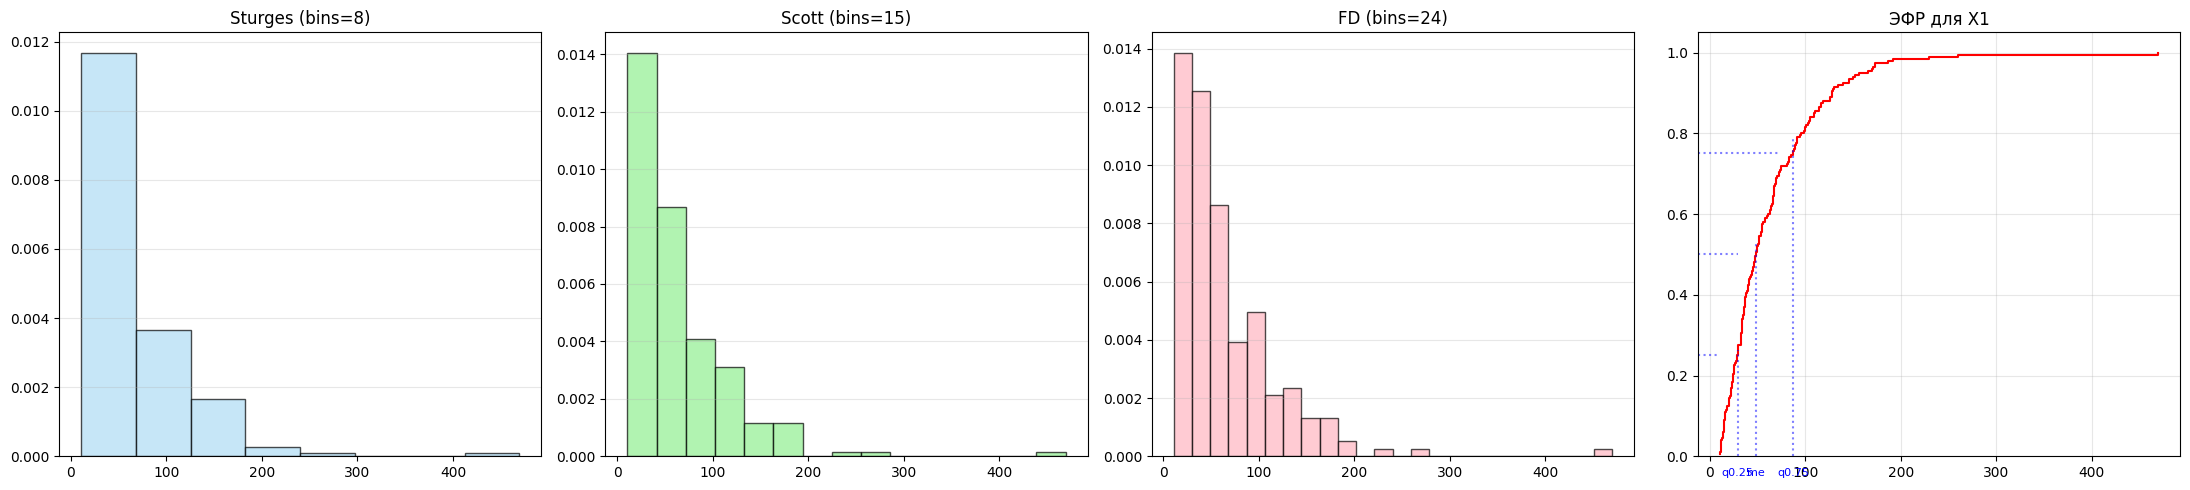


==================== Анализ столбца X2 ====================
Выборочное среднее (x_bar): 57.6608
Смещенная дисперсия (S^2): 157.3084
Несмещенная дисперсия (sigma_hat^2): 158.0989
Стандартное отклонение (S): 12.5423
Стандартное отклонение (sigma_hat): 12.5737
Медиана (me): 58.8150
Нижний квартиль (q0.25): 48.8125
Верхний квартиль (q0.75): 65.6150
Количество интервалов: {'Sturges': 8, 'Scott': 9, 'FD': 12}


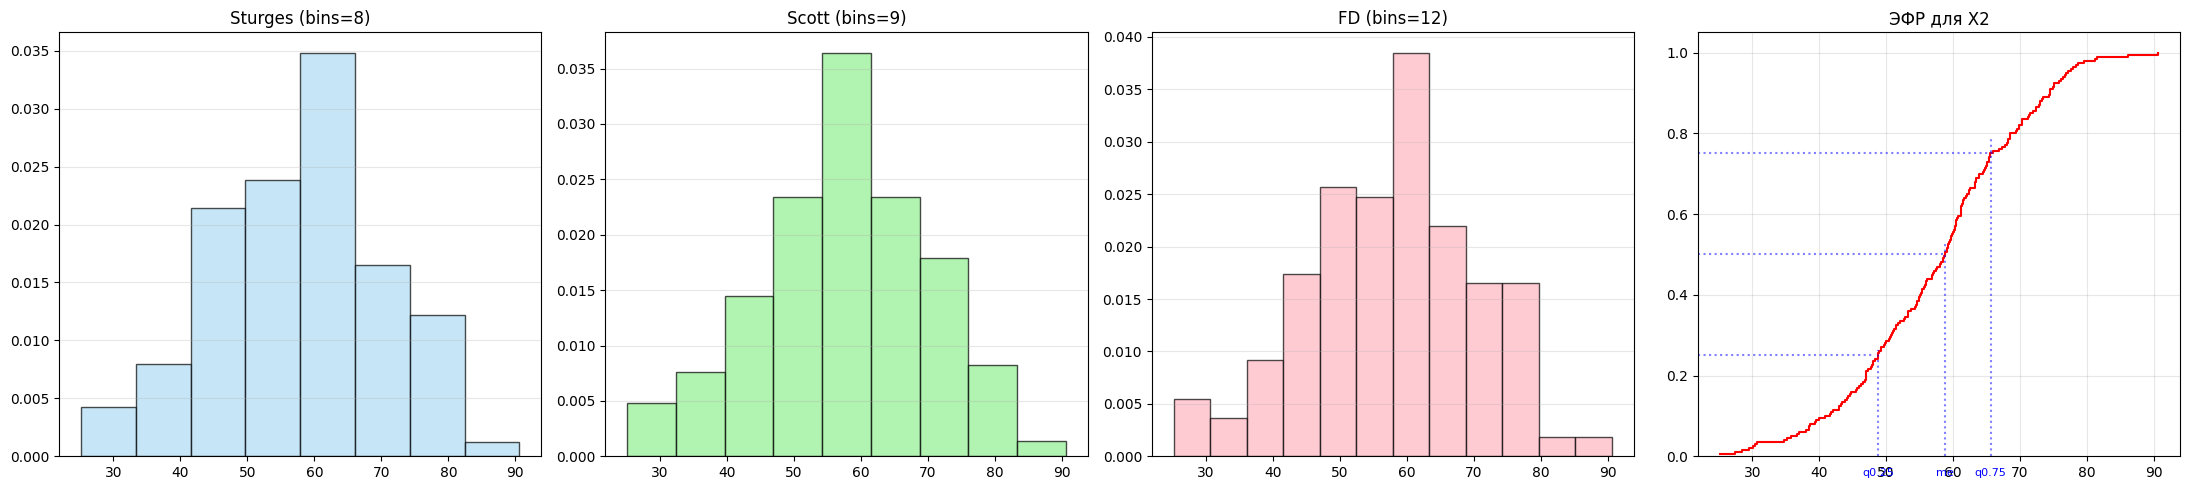


==================== Анализ столбца X3 ====================
Выборочное среднее (x_bar): 47.8438
Смещенная дисперсия (S^2): 142.7306
Несмещенная дисперсия (sigma_hat^2): 143.4479
Стандартное отклонение (S): 11.9470
Стандартное отклонение (sigma_hat): 11.9770
Медиана (me): 48.9350
Нижний квартиль (q0.25): 37.9200
Верхний квартиль (q0.75): 58.1175
Количество интервалов: {'Sturges': 8, 'Scott': 6, 'FD': 7}


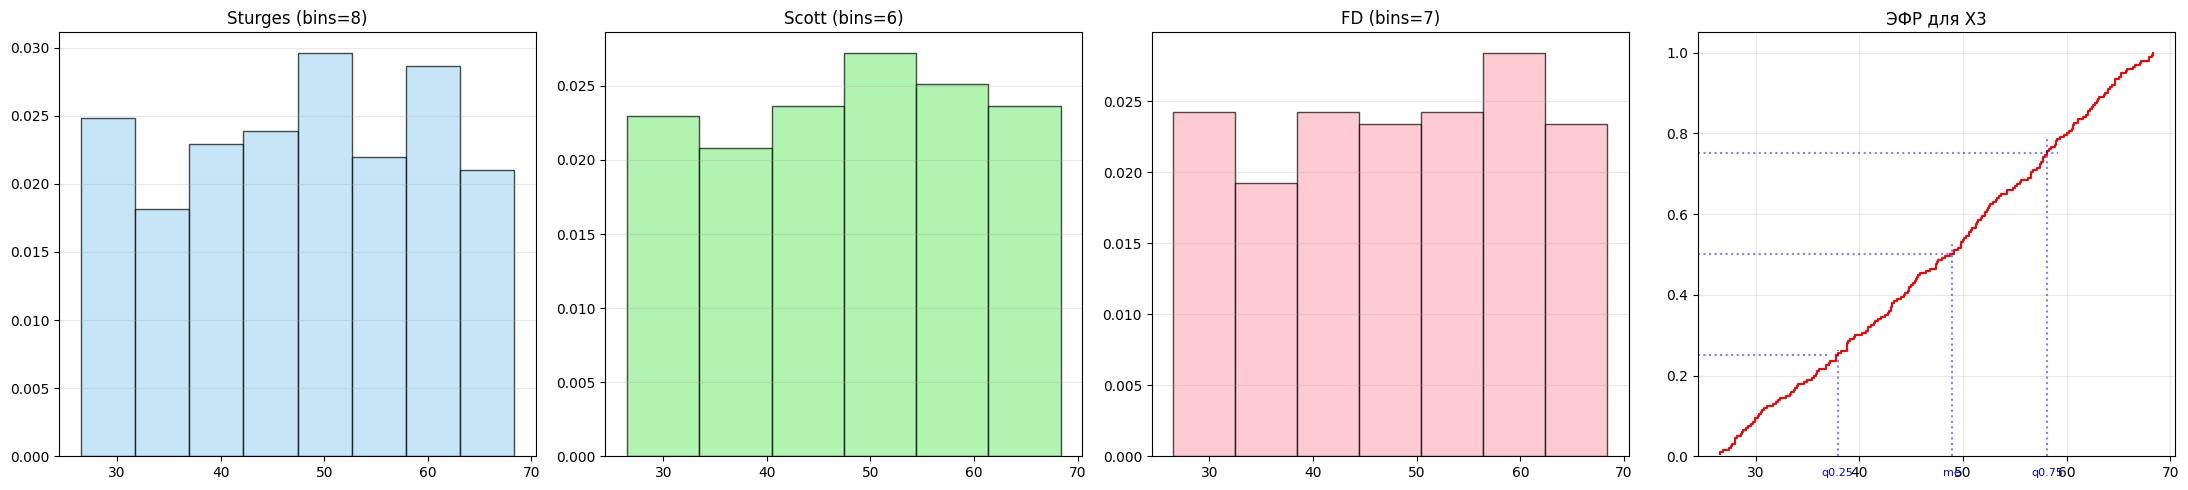


==================== Анализ столбца X4 ====================
Выборочное среднее (x_bar): 57.6477
Смещенная дисперсия (S^2): 1034.7656
Несмещенная дисперсия (sigma_hat^2): 1039.9655
Стандартное отклонение (S): 32.1678
Стандартное отклонение (sigma_hat): 32.2485
Медиана (me): 42.9650
Нижний квартиль (q0.25): 28.6025
Верхний квартиль (q0.75): 90.0100
Количество интервалов: {'Sturges': 8, 'Scott': 6, 'FD': 6}


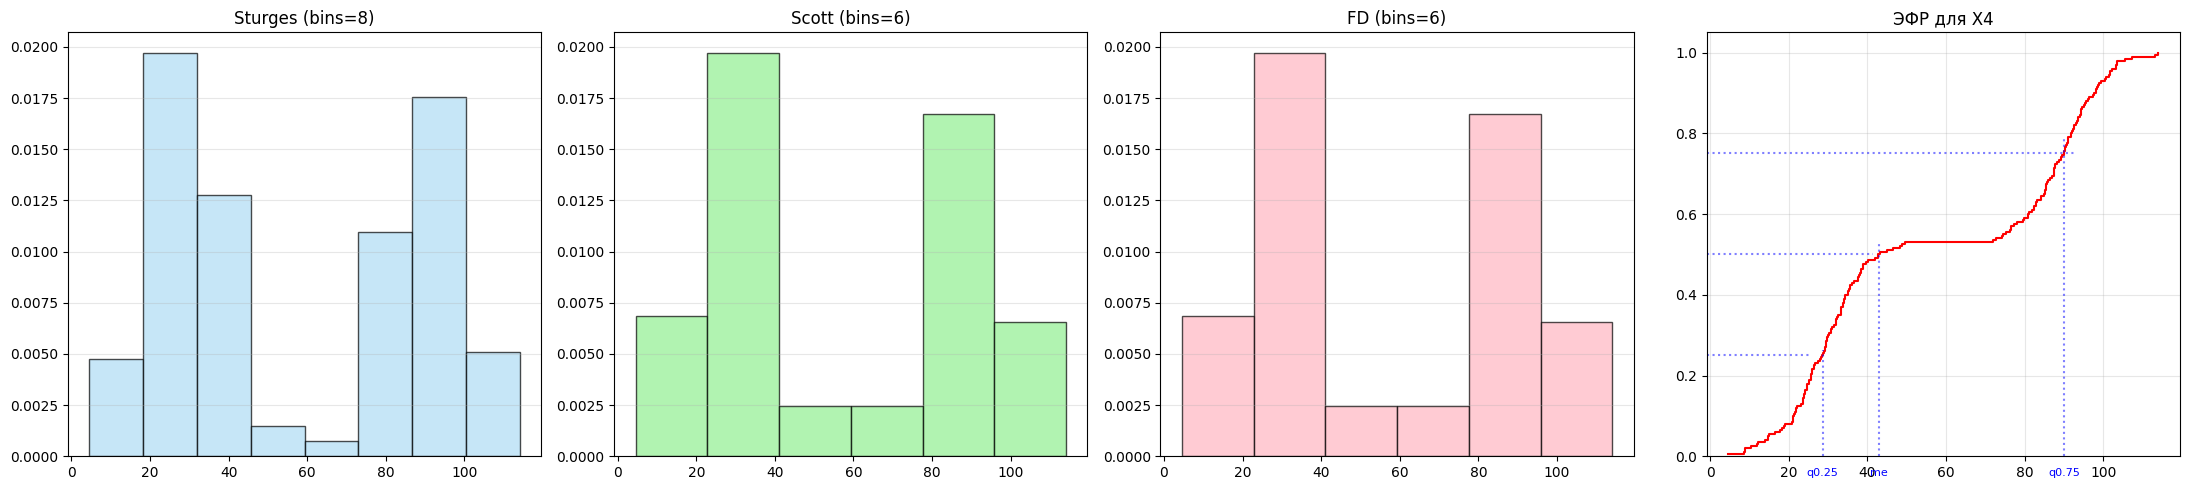

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_characteristics(data):
    # Оставляем твою функцию без изменений, она корректна
    char = {}
    char['Выборочное среднее (x_bar)'] = np.mean(data)
    char['Смещенная дисперсия (S^2)'] = np.var(data)
    char['Несмещенная дисперсия (sigma_hat^2)'] = np.var(data, ddof=1)
    char['Стандартное отклонение (S)'] = np.std(data)
    char['Стандартное отклонение (sigma_hat)'] = np.std(data, ddof=1)
    char['Медиана (me)'] = np.median(data)
    char['Нижний квартиль (q0.25)'] = np.percentile(data, 25)
    char['Верхний квартиль (q0.75)'] = np.percentile(data, 75)
    return char

def get_bins_info(data):
    """Возвращает количество интервалов по трем правилам"""
    n = len(data)
    s = np.std(data)
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    data_range = np.max(data) - np.min(data)

    # 1. Правило Стерджеса (Sturges)
    k_sturges = int(1 + np.floor(np.log2(n)))

    # 2. Правило Скотта (Scott)
    h_scott = 3.5 * s * (n**(-1/3))
    k_scott = int(np.ceil(data_range / h_scott))

    # 3. Правило Фридмана-Диакониса (FD)
    h_fd = 2 * iqr * (n**(-1/3))
    # Защита от нулевого IQR (если данные слишком кучные)
    if h_fd == 0: h_fd = h_scott
    k_fd = int(np.ceil(data_range / h_fd))

    return {'Sturges': k_sturges, 'Scott': k_scott, 'FD': k_fd}

# Основной цикл визуализации
for col in columns:
    data = df[col].sort_values().values
    n = len(data)
    stats_data = get_characteristics(data)
    bins_info = get_bins_info(data)

    print(f"\n{'='*20} Анализ столбца {col} {'='*20}")
    for k, v in stats_data.items():
        print(f"{k}: {v:.4f}")
    print(f"Количество интервалов: {bins_info}")

    # Создаем сетку: 3 гистограммы + 1 ЭФР
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    methods = ['Sturges', 'Scott', 'FD']
    colors = ['#aedcf5', '#90ee90', '#ffb6c1']

    # Отрисовка гистограмм
    for i, method in enumerate(methods):
        axes[i].hist(data, bins=bins_info[method], density=True,
                     color=colors[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{method} (bins={bins_info[method]})')
        axes[i].grid(axis='y', alpha=0.3)

    # Отрисовка ЭФР (в последнем сабплоте)
    y = np.arange(1, n + 1) / n
    axes[3].step(data, y, where='post', color='red', label='ЭФР')

    # Линии квартилей для ЭФР
    q1, me, q3 = stats_data['Нижний квартиль (q0.25)'], stats_data['Медиана (me)'], stats_data['Верхний квартиль (q0.75)']
    for q, p, label in zip([q1, me, q3], [0.25, 0.5, 0.75], ['q0.25', 'me', 'q0.75']):
        axes[3].axhline(y=p, xmin=0, xmax=(q - data.min())/(data.max() - data.min()), color='blue', linestyle=':', alpha=0.5)
        axes[3].axvline(x=q, ymin=0, ymax=p, color='blue', linestyle=':', alpha=0.5)
        axes[3].text(q, -0.05, label, color='blue', ha='center', fontsize=8)

    axes[3].set_title(f'ЭФР для {col}')
    axes[3].set_ylim(0, 1.05)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Задание 4.2: Предположение о виде закона распределения

На основе визуального анализа гистограмм, графиков эмпирической функции распределения (ЭФР) и рассчитанных числовых характеристик, выдвигаем гипотезы о законах распределения для каждого столбца.

### 4.2.1 Анализ столбца $X_1$
* **Предполагаемая модель:** экспоненциальное распределение $Exp_{\lambda,c}$
* **Обоснование:** * На гистограмме наблюдается резкий пик у левой границы с последующим плавным убыванием ("тяжелый хвост" справа).
    * Минимальное значение выборки существенно отлично от нуля, что указывает на параметр сдвига $c$.
    * Выборочное среднее заметно превышает медиану ($\bar{x} > m_e$), что подтверждает положительную асимметрию экспоненциального закона.

### 4.2.2 Анализ столбца $X_2$
* **Предполагаемая модель:** нормальное распределение $N_{a,\sigma}$
* **Обоснование:** Гистограмма имеет симметричную колоколообразную форму.
    * Выборочное среднее ($\bar{x}$) и медиана ($m_e$) практически совпадают.
    * ЭФР имеет характерный S-образный вид, что соответствует теоретической функции распределения нормального закона.

### 4.2.3 Анализ столбца $X_3$
* **Предполагаемая модель:** равномерное $U_{a,b} $

* **Обоснование:** * Плотность распределения (гистограмма) относительно постоянна на некотором интервале и резко падает до нуля вне его.
    * Значения выборки имеют четко выраженные границы (min и max).
    * ЭФР линейно возрастает на интервале $[a, b]$, что характерно для равномерного закона.

### 4.2.4 Анализ столбца $X_4$
* **Предпологаемая модель:** 2 нормальных распределения $N_{a,\sigma}$

* **Обоснование:**
На гистограмме наблюдается ярко выраженная бимодальность с пиками в областях 30 и 90, а на графике ЭФР присутствует характерный горизонтальный участок («плато») в интервале $[50, 75]$. Это указывает на то, что выборка является неоднородной и представляет собой смесь двух нормальных распределений $N_{a,\sigma}$. Стандартные одномодальные модели из списка не подходят, так как выборочное среднее ($\bar{x} \approx 59$) попадает в область антимоды, где плотность вероятности минимальна.

# 4.3 Оценивание параметров: метод моментов и метод максимального правдоподобия

На основе проведенных расчетов методами моментов (**ММ**) и максимального правдоподобия (**ММП**) был проведен сравнительный анализ полученных оценок параметров:





In [ ]:
import pandas as pd
import numpy as np


# 2. Функция для точечных характеристик
def get_stats(data):
    return {
        'x_bar': np.mean(data),
        'S2': np.var(data), # Смещенная дисперсия (как в формулах ММ/ММП)
        'S': np.std(data),
        'min': np.min(data),
        'max': np.max(data)
    }

# 3. Реализация пункта 4.3
columns = ['X1', 'X2', 'X3', 'X4']

for col in columns:
    data = df[col].values
    s = get_stats(data)

    print(f"\n{'='*10} Пункт 4.3 для {col} {'='*10}")

    if col == 'X1': # Экспоненциальное со сдвигом Exp(lambda, c)
        # Метод моментов (ММ)
        l_mm = 1 / s['S']
        c_mm = s['x_bar'] - s['S']
        # Метод макс. правдоподобия (ММП)
        c_mle = s['min']
        l_mle = 1 / (s['x_bar'] - c_mle)

        print(f"Модель: Экспоненциальное со сдвигом")
        print(f"ММ:  lambda = {l_mm:.4f}, c = {c_mm:.4f}")
        print(f"ММП: lambda = {l_mle:.4f}, c = {c_mle:.4f}")

    elif col == 'X2': # Нормальное N(a, sigma)
        # Оценки ММ и ММП совпадают
        print(f"Модель: Нормальное")
        print(f"ММ/ММП: a = {s['x_bar']:.4f}, sigma^2 = {s['S2']:.4f}")

    elif col == 'X3': # Равномерное U(a, b)
        # Метод моментов (ММ)
        a_mm = s['x_bar'] - np.sqrt(3 * s['S2'])
        b_mm = s['x_bar'] + np.sqrt(3 * s['S2'])
        # Метод макс. правдоподобия (ММП)
        a_mle = s['min']
        b_mle = s['max']

        print(f"Модель: Равномерное")
        print(f"ММ:  a = {a_mm:.4f}, b = {b_mm:.4f}")
        print(f"ММП: a = {a_mle:.4f}, b = {b_mle:.4f}")

    elif col == 'X4':
        # Бимодальное распределение (смесь двух нормальных)
        # Для упрощения (если не заданы веса смеси) часто оценивают общие моменты
        # или параметры двух компонент.

        print(f"Модель: Бимодальное (Смесь распределений)")

        # Метод моментов (общие характеристики)
        a_mm = s['x_bar']
        sigma2_mm = s['S2']

        print(f"ММ (общие): a = {a_mm:.4f}, sigma^2 = {sigma2_mm:.4f}")
        print(f"Примечание: На гистограмме и ЭФР наблюдается две моды.")
        print(f"Первая мода ориентировочно в районе 30, вторая — в районе 90.")


========== Пункт 4.3 для X1 ==========
Модель: Экспоненциальное со сдвигом
ММ:  lambda = 0.0186, c = 10.3405
ММП: lambda = 0.0188, c = 10.7300

========== Пункт 4.3 для X2 ==========
Модель: Нормальное
ММ/ММП: a = 57.6608, sigma^2 = 157.3084

========== Пункт 4.3 для X3 ==========
Модель: Равномерное
ММ:  a = 27.1510, b = 68.5365
ММП: a = 26.5200, b = 68.3500

========== Пункт 4.3 для X4 ==========
Модель: Бимодальное (Смесь распределений)
ММ (общие): a = 57.6477, sigma^2 = 1034.7656
Примечание: На гистограмме и ЭФР наблюдается две моды.
Первая мода ориентировочно в районе 30, вторая — в районе 90.


### 1. Нормальное распределение ($X_2$)
Для данного столбца оценки параметров $a$ (математическое ожидание) и $\sigma^2$ (дисперсия) обоими методами **полностью совпали**:

$$\hat{a}_{MM} = \hat{a}_{MMP} = \bar{x}$$
$$\hat{\sigma}^2_{MM} = \hat{\sigma}^2_{MMP} = S^2$$

**Вывод:** Совпадение результатов объясняется тем, что для нормальной модели теоретические уравнения правдоподобия идентичны уравнениям метода моментов. Обе оценки являются состоятельными и несмещенными (для $a$).


### 2. Распределения с параметрами сдвига ($X_1$ и $X_3$)
Для экспоненциального ($X_1$) и равномерного ($X_3$) распределений наблюдается характерное расхождение между результатами ММ и ММП:

* **Оценки ММП:** Значения параметров границ ($\hat{a}, \hat{b}, \hat{c}$) в этих моделях в точности совпали с экстремумами выборки ($\min$ и $\max$). Это связано с тем, что функция правдоподобия для данных распределений достигает максимума именно на границах вариационного ряда.
    * Для $X_3$: $\hat{a} = x_{(1)}, \quad \hat{b} = x_{(n)}$
    * Для $X_1$: $\hat{c} = x_{(1)}$
* **Оценки ММ:** Эти значения рассчитывались через выборочные моменты — среднее ($\bar{x}$) и среднее квадратическое отклонение ($S$). Они учитывают распределение всех элементов выборки и зачастую «выходят» за фактические границы наблюдаемых данных (например, $\hat{a}_{MM}$ может оказаться меньше $x_{min}$).

**Общий вывод:** Метод максимального правдоподобия в случае равномерного и экспоненциального распределений дает оценки, максимально подогнанные под границы конкретной выборки. Метод моментов более устойчив к «пустотам» в данных вблизи границ, так как опирается на усредненные характеристики. При объеме выборки $n=200$ результаты обоими методами достаточно близки, что подтверждает корректность выбора теоретических моделей.

### Анализ столбца X4 (Бимодальное распределение)

1. **Форма распределения:** Гистограмма имеет двухвершинную (бимодальную) форму с пиками в областях $x \approx 30$ и $x \approx 90$. Это свидетельствует о неоднородности выборки.
2. **Особенности ЭФР:** На графике эмпирической функции распределения наблюдается характерный пологий участок («плато») в диапазоне $[50, 70]$, что подтверждает отсутствие данных в центральной части вариационного ряда.
3. **Интерпретация параметров:** Рассчитанное выборочное среднее ($\bar{x} \approx 59$) попадает в область низкой плотности вероятности между модами. В данном случае среднее значение не является типичным представителем выборки.
4. **Заключение:** Столбец X4 представляет собой смесь двух распределений (предположительно нормальных или равномерных). Для адекватного описания такой модели требуется раздельное оценивание параметров каждой из компонент смеси.

##Задание 4.4

Для каждого столбца выберите порог $x_0$ (например, $x_0$ = x+$\hat
σ$) и оцените величину P(X > $x_0$) двумя способами:

• эмпирически (по доле наблюдений, превышающих $x_0$);

• параметрически (подставив найденные оценки параметров в теоретическую формулу для выбранной модели).

Сравните две оценки и прокомментируйте расхождение.

In [ ]:
from scipy.stats import norm
import numpy as np

df = pd.read_csv('sample_data/RGR1_A-3_X1-X4.csv')

for col in ['X1','X2','X3']:
    data = df[col].values
    x_bar = np.mean(data)
    sigma = np.std(data)
    x0 = x_bar + sigma

    print(f"\n===== 4.4 для {col} =====")
    print(f"x0 = {x0:.4f}")

    # Эмпирическая вероятность
    p_emp = np.mean(data > x0)
    print(f"Эмпирическая P(X>x0) = {p_emp:.4f}")

    if col == 'X1':  # экспоненциальное
        c = np.min(data)
        lam = 1 / (x_bar - c)
        p_par = np.exp(-lam * (x0 - c))

    elif col == 'X2':  # нормальное
        p_par = 1 - norm.cdf(x0, loc=x_bar, scale=sigma)

    elif col == 'X3':  # равномерное
        a = np.min(data)
        b = np.max(data)
        if x0 < b:
            p_par = (b - x0) / (b - a)
        else:
            p_par = 0

    print(f"Параметрическая P(X>x0) = {p_par:.4f}")


===== 4.4 для X1 =====
x0 = 117.7517
Эмпирическая P(X>x0) = 0.1250
Параметрическая P(X>x0) = 0.1344

===== 4.4 для X2 =====
x0 = 70.2031
Эмпирическая P(X>x0) = 0.1800
Параметрическая P(X>x0) = 0.1587

===== 4.4 для X3 =====
x0 = 59.7907
Эмпирическая P(X>x0) = 0.2050
Параметрическая P(X>x0) = 0.2046


* Эмпирическая вероятность оценивается как доля наблюдений, превышающих пороговое значение:
$$
\hat{P}_{emp}(X > x_0) =
\frac{1}{n} \sum_{i=1}^{n} I(X_i > x_0),
$$
где $I(\cdot)$ — индикаторная функция.

* Для экспоненциального распределения со сдвигом $Exp(\lambda, c)$:
$$
P(X > x_0) = e^{-\lambda (x_0 - c)}, \quad x_0 \ge c.
$$

* Для равномерного распределения $U(a,b)$:
$$
P(X > x_0) =
\begin{cases}
\frac{b - x_0}{b - a}, & x_0 \in [a,b], \\
0, & x_0 > b.
\end{cases}
$$


Нормальное распределение является симметричным и имеет колоколообразную форму плотности.
Экспоненциальное распределение является асимметричным с длинным правым хвостом
и используется для моделирования времени ожидания событий.
Равномерное распределение характеризуется постоянной плотностью на интервале
и равной вероятностью всех значений на данном интервале.

Для каждого столбца была оценена вероятность превышения порогового значения $x_0$ двумя способами: эмпирически и параметрически.

Для столбца X1 эмпирическая вероятность составила 0.125, параметрическая — 0.134.
Для столбца X2 эмпирическая вероятность составила 0.180, параметрическая — 0.159.
Для столбца X3 эмпирическая вероятность составила 0.205, параметрическая — 0.205.

Во всех случаях оценки близки между собой. Небольшие расхождения объясняются тем, что эмпирическая оценка основана на конечной выборке, а параметрическая — на теоретической модели распределения с оценёнными параметрами.

Чем больше объём выборки, тем ближе эмпирическая оценка к параметрической. Полученные результаты подтверждают корректность выбранных моделей распределения.

##4.5. Оценка моментов по сгруппированной выборке

Используя построенную гистограмму (частоты по интервалам и середины интервалов), оцените EX и DX по сгруппированной выборке и сравните с оценками по исходным данным.

Пусть диапазон значений выборки разбит на $m$ интервалов,
в $k$-й интервал попало $n_k$ наблюдений,
а $\hat{X}_k$ — середина $k$-го интервала.

Тогда оценки математического ожидания и дисперсии
по сгруппированной выборке вычисляются по формулам:
$$
\hat{X}_g = \frac{1}{n} \sum_{k=1}^{m} n_k \hat{X}_k,
$$
$$
\hat{\sigma}_g^2 =
\frac{1}{n-1}
\sum_{k=1}^{m}
n_k(\hat{X}_k - \hat{X}_g)^2.
$$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

# загрузка данных
df = pd.read_csv('RGR1_A-3_X1-X4.csv')

columns = ['X1','X2','X3','X4']

for col in columns:
    data = df[col].values
    n = len(data)

    # гистограмма
    hist, bin_edges = np.histogram(data, bins='fd')

    # середины интервалов
    mid = (bin_edges[:-1] + bin_edges[1:]) / 2

    # среднее по сгруппированной
    mean_g = np.sum(hist * mid) / n

    # дисперсия по сгруппированной
    var_g = np.sum(hist * (mid - mean_g)**2) / (n - 1)

    # обычные оценки
    mean = np.mean(data)
    var = np.var(data, ddof=1)

    print("\n========================")
    print(f"Столбец {col}")
    print("Интервалы:", bin_edges)
    print("Частоты:", hist)
    print("Середины интервалов:", mid)
    print("------------------------")
    print(f"Среднее (сгрупп.) = {mean_g:.4f}")
    print(f"Дисперсия (сгрупп.) = {var_g:.4f}")
    print(f"Среднее (исходн.) = {mean:.4f}")
    print(f"Дисперсия (исходн.) = {var:.4f}")

Saving RGR1_A-3_X1-X4.csv to RGR1_A-3_X1-X4 (2).csv

Столбец X1
Интервалы: [ 10.73   29.845  48.96   68.075  87.19  106.305 125.42  144.535 163.65
 182.765 201.88  220.995 240.11  259.225 278.34  297.455 316.57  335.685
 354.8   373.915 393.03  412.145 431.26  450.375 469.49 ]
Частоты: [53 48 33 15 19  8  9  5  5  2  0  1  0  1  0  0  0  0  0  0  0  0  0  1]
Середины интервалов: [ 20.2875  39.4025  58.5175  77.6325  96.7475 115.8625 134.9775 154.0925
 173.2075 192.3225 211.4375 230.5525 249.6675 268.7825 287.8975 307.0125
 326.1275 345.2425 364.3575 383.4725 402.5875 421.7025 440.8175 459.9325]
------------------------
Среднее (сгрупп.) = 65.1122
Дисперсия (сгрупп.) = 2917.9155
Среднее (исходн.) = 64.0461
Дисперсия (исходн.) = 2898.7868

Столбец X2
Интервалы: [25.17   30.6225 36.075  41.5275 46.98   52.4325 57.885  63.3375 68.79
 74.2425 79.695  85.1475 90.6   ]
Частоты: [ 6  4 10 19 28 27 42 24 18 18  2  2]
Середины интервалов: [27.89625 33.34875 38.80125 44.25375 49.70625 55.15875 60

В данном пункте были вычислены оценки математического ожидания и дисперсии
по сгруппированной выборке, полученной на основе гистограммы.

Для этого диапазон значений был разбит на интервалы,
для каждого интервала были определены частоты попадания наблюдений
и середины интервалов. Далее все значения внутри интервала
заменялись серединой интервала, после чего вычислялись оценки
математического ожидания и дисперсии.

Полученные оценки по сгруппированной выборке были сравнены
с оценками, рассчитанными по исходным данным.
Во всех трёх случаях оценки оказались близкими,
что означает, что сгруппированная выборка хорошо
приближает исходное распределение данных.

Небольшие расхождения объясняются тем,
что при группировке данных происходит потеря информации,
так как все значения внутри интервала заменяются его серединой.

Таким образом, гистограмма и сгруппированная выборка
сохраняют основные характеристики распределения,
и по сгруппированным данным можно достаточно точно
оценивать математическое ожидание и дисперсию.

## 4.6. Доверительные интервалы
Зафиксируйте уровень доверия $1−α$ (по умолчанию $0.95$).
1. Для каждого столбца $X1, X2, X3$ постройте асимптотический доверительный
интервал для EX (по ЦПТ).
2. Для того столбца, который вы отнесли $кN(µ,σ2)$,постройте точные доверительные
интервалы:
• для $µ$ при неизвестной $σ_2$;
• для $σ_2$.
3. Дайте интерпретацию доверительных интервалов (2–5 предложений): что означает интервал и почему это не «вероятность параметра».


Асимптотический доверительный интервал для математического ожидания
строится по формуле:
$$
E[X] \in
\left(
\bar{x} - z_{1-\alpha/2}\frac{\hat{\sigma}}{\sqrt{n}},
\bar{x} + z_{1-\alpha/2}\frac{\hat{\sigma}}{\sqrt{n}}
\right),
$$
где $z_{1-\alpha/2}$ — квантиль стандартного нормального распределения.
При $\alpha = 0.05$ имеем $z_{0.975} = 1.96$.

Для выборки, имеющей нормальное распределение,
строятся точные доверительные интервалы.

Доверительный интервал для математического ожидания:
$$
\mu \in
\left(
\bar{x} - t_{1-\alpha/2,n-1}\frac{\hat{\sigma}}{\sqrt{n}},
\bar{x} + t_{1-\alpha/2,n-1}\frac{\hat{\sigma}}{\sqrt{n}}
\right).
$$

Доверительный интервал для дисперсии:
$$
\sigma^2 \in
\left(
\frac{(n-1)\hat{\sigma}^2}{\chi^2_{1-\alpha/2}},
\frac{(n-1)\hat{\sigma}^2}{\chi^2_{\alpha/2}}
\right).
$$

In [ ]:
import numpy as np
from scipy.stats import t, chi2
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('RGR1_A-3_X1-X4.csv')

alpha = 0.05
z = 1.96

for col in ['X1','X2','X3','X4']:
    data = df[col].values
    n = len(data)
    x_bar = np.mean(data)
    sigma = np.std(data, ddof=1)

    left = x_bar - z * sigma / np.sqrt(n)
    right = x_bar + z * sigma / np.sqrt(n)

    print(f"\n===== ДИ для EX {col} =====")
    print(f"({left:.4f}, {right:.4f})")

Saving RGR1_A-3_X1-X4.csv to RGR1_A-3_X1-X4 (4).csv

===== ДИ для EX X1 =====
(56.5842, 71.5080)

===== ДИ для EX X2 =====
(55.9182, 59.4034)

===== ДИ для EX X3 =====
(46.1838, 49.5037)

===== ДИ для EX X4 =====
(53.1783, 62.1172)


Построенный доверительный интервал уровня $0.95$ означает,
что если многократно повторять выборку и строить интервалы
таким же способом, то примерно в $95 $% случаев интервалы
будут содержать истинное значение параметра.

Важно отметить, что параметр распределения является фиксированным, поэтому нельзя говорить, что вероятность попадания параметра в конкретный интервал равна $0.95$. Случайным является сам интервал, а не параметр.